### Initialisation : Nettoyage et Merge

In [4]:
import pandas as pd
import numpy as np

# 1. Chargement des données
path_cardio = "../data/raw/cardio_train.csv"
path_nhanes = "../data/raw/Nhanes_cvd_raw.csv"

df_cardio = pd.read_csv(path_cardio, sep=';')
df_nhanes = pd.read_csv(path_nhanes)

# 2. Nettoyage initial : Filtrage des pressions artérielles (Plages physiologiques)
# On retire les valeurs aberrantes avant de faire les calculs de stades
df_cardio = df_cardio[(df_cardio['ap_hi'] >= 80) & (df_cardio['ap_hi'] <= 220)]
df_cardio = df_cardio[(df_cardio['ap_lo'] >= 50) & (df_cardio['ap_lo'] <= 120)]

# 3. Feature Engineering de base (Âge et IMC)
# Conversion de l'âge de jours en années
df_cardio['age_years'] = (df_cardio['age'] / 365.25).astype(int)

# Calcul de l'IMC pour cardio_train
df_cardio['bmi'] = df_cardio['weight'] / ((df_cardio['height'] / 100) ** 2)

# 4. Préparation des catégories pour la fusion statistique
# Tranches d'âge pour stabiliser les moyennes
age_bins = [0, 30, 35, 40, 45, 50, 55, 60, 65, 100]
age_labels = ['0-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65+']

df_cardio['age_group'] = pd.cut(df_cardio['age_years'], bins=age_bins, labels=age_labels)
df_nhanes['age_group'] = pd.cut(df_nhanes['Age'], bins=age_bins, labels=age_labels)

# Catégorisation de l'IMC[cite: 1, 2]
def get_bmi_cat(bmi):
    if bmi < 18.5: return 'Underweight'
    if bmi < 25: return 'Normal'
    if bmi < 30: return 'Overweight'
    return 'Obese'

df_cardio['bmi_cat'] = df_cardio['bmi'].apply(get_bmi_cat)
df_nhanes['bmi_cat'] = df_nhanes['BMI'].apply(get_bmi_cat)

# 5. Calcul des moyennes et Fusion avec NHANES
# Création de la table de référence depuis NHANES[cite: 1, 2]
reference_table = df_nhanes.groupby(['age_group', 'bmi_cat'])[['C_Reactive', 'Sodium', 'Saturated_Fat']].mean().reset_index()

# Injection des moyennes dans le dataset principal[cite: 1, 2]
df_merged = pd.merge(
    df_cardio, 
    reference_table, 
    on=['age_group', 'bmi_cat'], 
    how='left'
)

# 6. Feature Engineering Avancé : Stade d'Hypertension
# Création des paliers médicaux basés sur les pressions nettoyées[cite: 1, 2]
def get_hypertension_stage(row):
    hi = row['ap_hi']
    lo = row['ap_lo']
    if hi < 120 and lo < 80:
        return 0 # Normal
    elif (120 <= hi < 130) and lo < 80:
        return 1 # Élevée
    elif (130 <= hi < 140) or (80 <= lo < 90):
        return 2 # Stade 1
    else:
        return 3 # Stade 2 / Crise

df_merged['hypertension_stage'] = df_merged.apply(get_hypertension_stage, axis=1)

# 7. Sauvegarde du dataset final enrichi et nettoyé
output_path = "../data/processed/df_final.csv"
df_merged.to_csv(output_path, index=False)

print("Traitement terminé avec succès !")
print(f"Lignes après filtrage BP : {len(df_merged)}")
print(f"Colonnes ajoutées : Sodium, C_Reactive, hypertension_stage")
print(df_merged[['age_years', 'ap_hi', 'ap_lo', 'hypertension_stage', 'C_Reactive']].head())

C:\Users\louis\AppData\Local\Temp\ipykernel_15384\3357109610.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reference_table = df_nhanes.groupby(['age_group', 'bmi_cat'])[['C_Reactive', 'Sodium', 'Saturated_Fat']].mean().reset_index()


Traitement terminé avec succès !
Lignes après filtrage BP : 68636
Colonnes ajoutées : Sodium, C_Reactive, hypertension_stage
   age_years  ap_hi  ap_lo  hypertension_stage  C_Reactive
0         50    110     80                   2    2.216181
1         55    140     90                   3    6.242231
2         51    130     70                   2    2.162735
3         48    150    100                   3    3.325836
4         47    100     60                   0    2.216181


--- % de valeurs manquantes par variable ---
                    % Manquant
id                         0.0
active                     0.0
Saturated_Fat              0.0
Sodium                     0.0
C_Reactive                 0.0
bmi_cat                    0.0
age_group                  0.0
bmi                        0.0
age_years                  0.0
cardio                     0.0
alco                       0.0
age                        0.0
smoke                      0.0
gluc                       0.0
cholesterol                0.0
ap_lo                      0.0
ap_hi                      0.0
weight                     0.0
height                     0.0
gender                     0.0
hypertension_stage         0.0


C:\Users\louis\AppData\Local\Temp\ipykernel_15384\2518772370.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cardio', y='bmi', data=df, ax=axes[1, 0], palette='Set2')


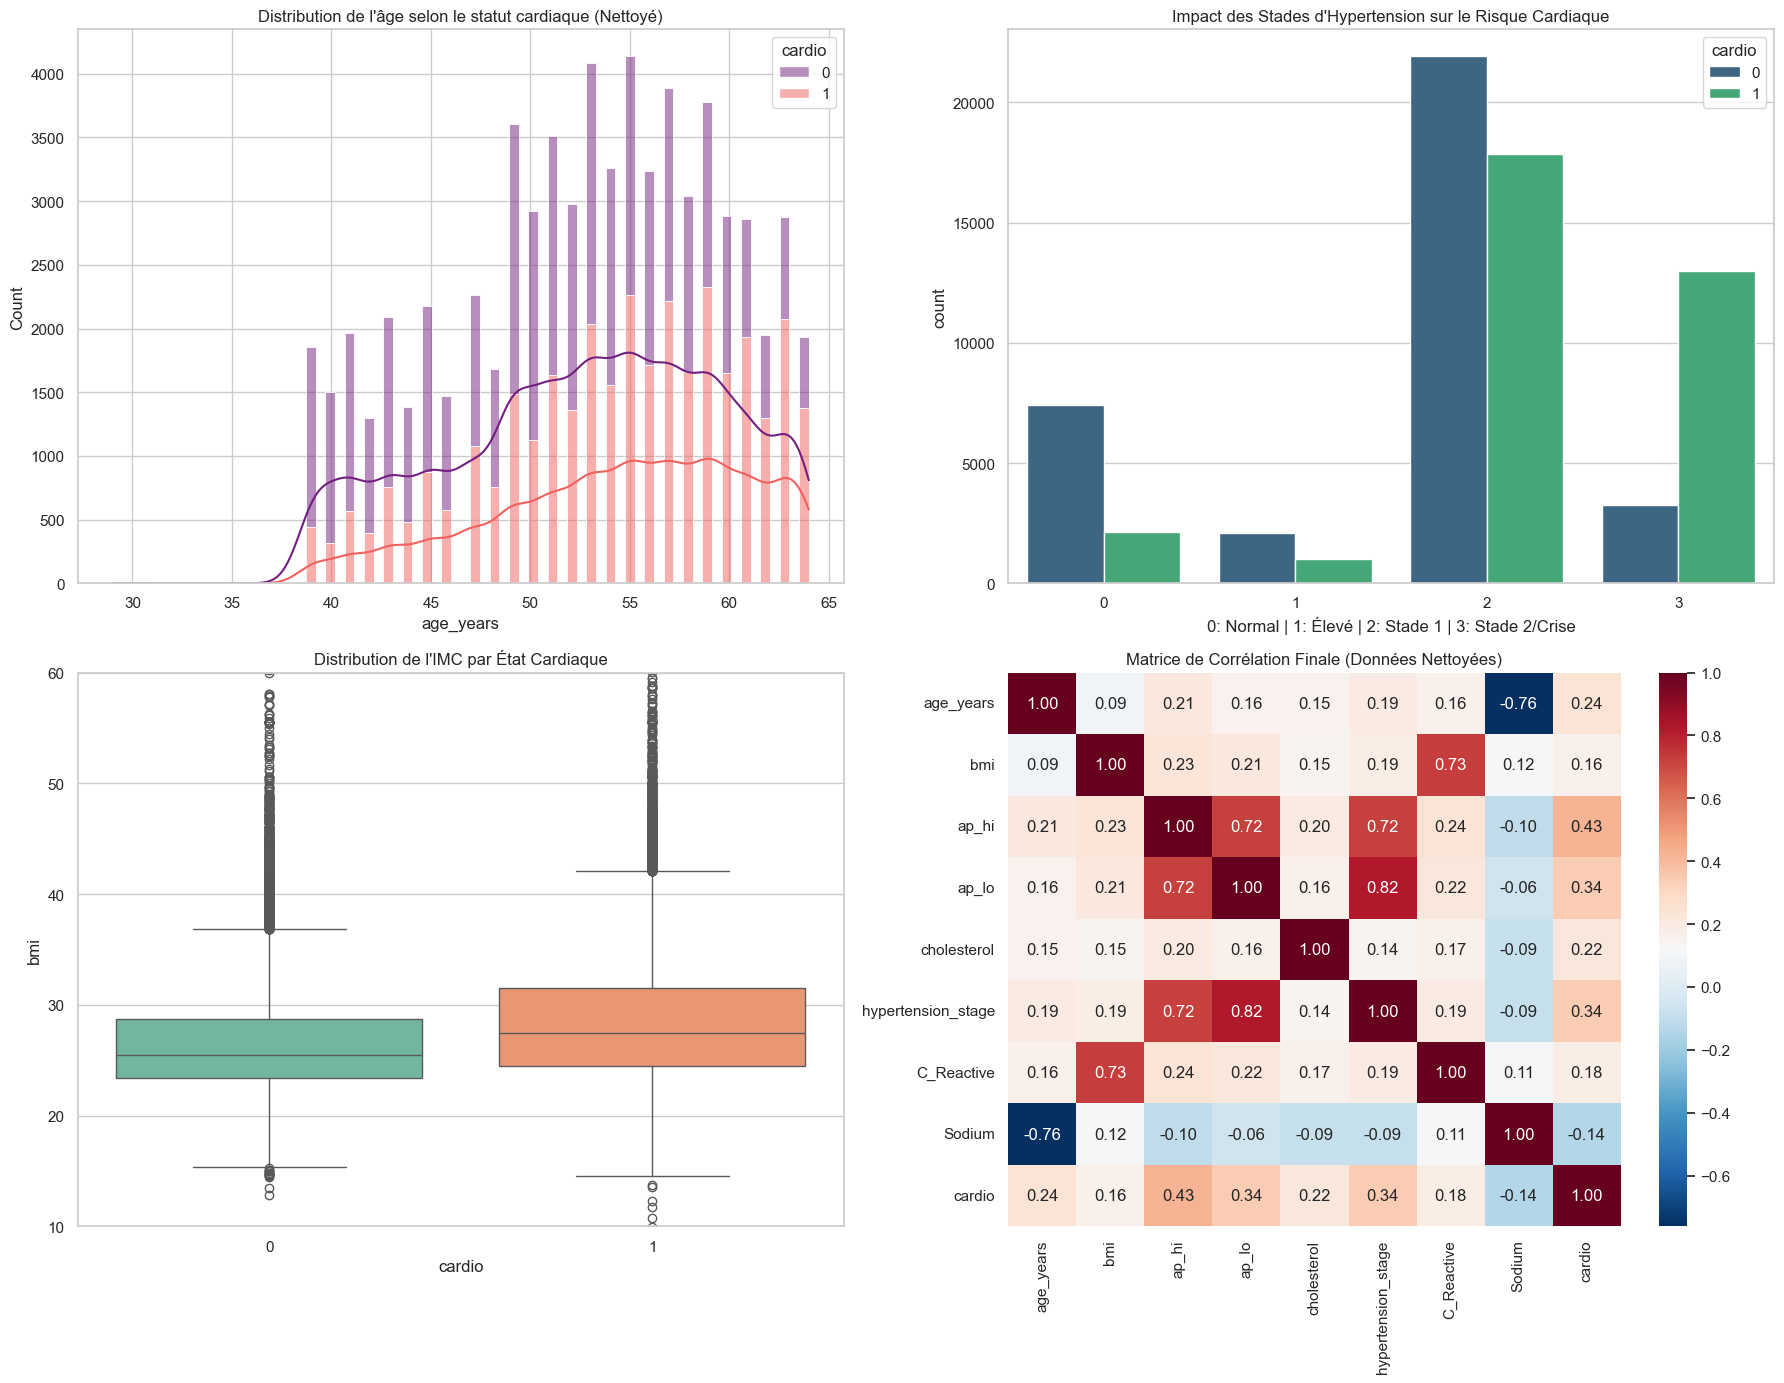

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le dataset final
df = pd.read_csv('../data/processed/df_final.csv')

# 1. Analyse des valeurs manquantes
missing_pct = (df.isnull().sum() / len(df)) * 100
print("--- % de valeurs manquantes par variable ---")
print(missing_pct.to_frame(name='% Manquant').sort_values(by='% Manquant', ascending=False))

# 2. Visualisations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
sns.set_theme(style="whitegrid")

# Graphique 1 : Distribution de l'âge (Histogramme empilé)
sns.histplot(data=df, x='age_years', hue='cardio', kde=True, ax=axes[0, 0], palette='magma', multiple="stack")
axes[0, 0].set_title('Distribution de l\'âge selon le statut cardiaque (Nettoyé)')

# Graphique 2 : Répartition des Stades d'Hypertension
sns.countplot(x='hypertension_stage', hue='cardio', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Impact des Stades d\'Hypertension sur le Risque Cardiaque')
axes[0, 1].set_xlabel('0: Normal | 1: Élevé | 2: Stade 1 | 3: Stade 2/Crise')

# Graphique 3 : IMC vs Cardio (Boxplot)
sns.boxplot(x='cardio', y='bmi', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Distribution de l\'IMC par État Cardiaque')
axes[1, 0].set_ylim(10, 60) # Élimine visuellement les quelques outliers extrêmes d'IMC

# Graphique 4 : Matrice de corrélation finale
cols = ['age_years', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol', 'hypertension_stage', 'C_Reactive', 'Sodium', 'cardio']
sns.heatmap(df[cols].corr(), annot=True, cmap='RdBu_r', fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Matrice de Corrélation Finale (Données Nettoyées)')

plt.tight_layout()
plt.show()